# Regression Final Project - Medical Insurance dataset
**Author:** Jarred Gastreich 
**Date:** November, 25, 2025 
**Objective:** This project uses regression alalysis to determine insurance charges based on age, BMI and smoking status.


In [15]:
# Imports

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Section 1 Load and Inspect Data

In [16]:
# Load insurance dataset from data folder and verify
insurance = pd.read_csv(r"C:\Repos\ml-modules\notebooks\ml_regression_jarred\data\insurance.csv")
print(insurance.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [17]:
# 1. Check for missing values in every column
print("Missing Values per Column:")
print(insurance.isnull().sum())

print("\n" + "-"*30 + "\n")

# 2. Display summary statistics for numeric columns
print("Summary Statistics:")
print(insurance.describe())

# 3. Check data types of each column
print("\nData Types:")
print(insurance.dtypes)


Missing Values per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

------------------------------

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## Section 1 Relfection

The data has no missing values meaning every cell is complete for each feature. The statistics tell us that on average, each insured person has 1 child and is charged $13270, has a BMI of 30 and is around 39 years old.

# Section 2. Data Exploration and Prep

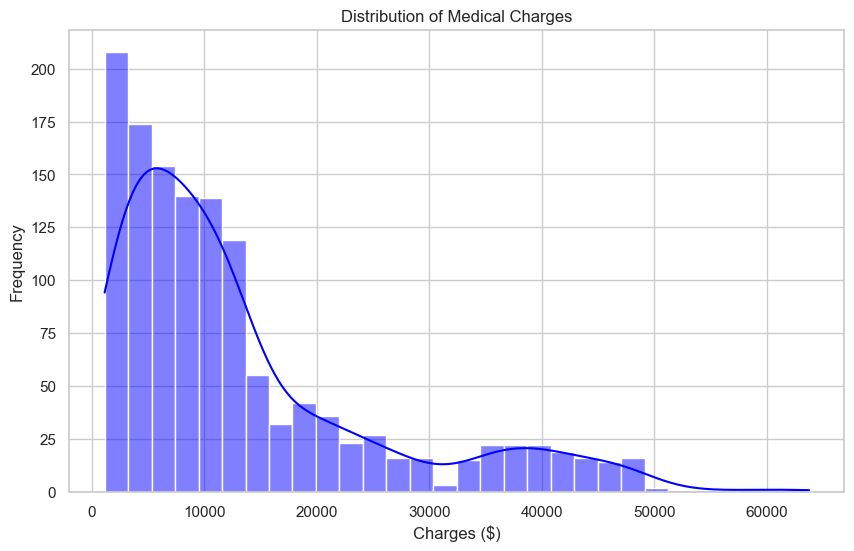

Skewness: 1.52


In [18]:
# Explore data patterns and distributions
# Set a clean visual style
sns.set(style="whitegrid")

# 1. Create the Histogram
plt.figure(figsize=(10, 6))
sns.histplot(insurance['charges'], kde=True, color='blue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

# 2. Calculate the Skewness number
skew_value = insurance['charges'].skew()
print(f"Skewness: {skew_value:.2f}")

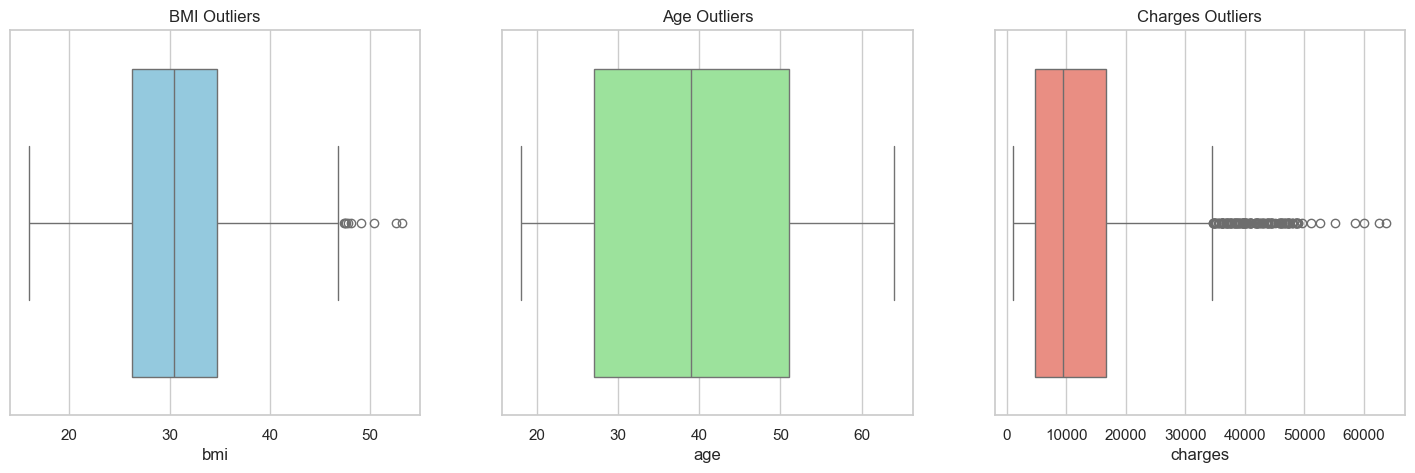

In [21]:
# Check Outliers

# Set up a grid of 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot for BMI
sns.boxplot(ax=axes[0], x=insurance['bmi'], color='skyblue')
axes[0].set_title('BMI Outliers')

# Boxplot for Age
sns.boxplot(ax=axes[1], x=insurance['age'], color='lightgreen')
axes[1].set_title('Age Outliers')

# Boxplot for Charges
sns.boxplot(ax=axes[2], x=insurance['charges'], color='salmon')
axes[2].set_title('Charges Outliers')

plt.show()

In [29]:
# List the columns you created
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']

# Sum them up to get the frequency
region_counts = insurance[region_cols].sum()

print("Counts per engineered region:")
print(region_counts)

# Calculate total rows
total_rows = len(insurance)

# Calculate the implied count of the reference category (Northeast)
northeast_count = total_rows - region_counts.sum()

print(f"Implied count for region_northeast (Reference): {northeast_count}")

Counts per engineered region:
region_northwest    325
region_southeast    364
region_southwest    325
dtype: int64
Implied count for region_northeast (Reference): 324


In [37]:
# Section 2.2 Clean Data - Convert categorical Data to numerical format

# Convert sex column to numerical
insurance['sex'] = insurance['sex'].map({'male': 0, 'female': 1})   

# Convert smoker column to numerical
insurance['smoker'] = insurance['smoker'].map({'no': 0, 'yes': 1})

# Create the region_northeast column: 1 if all others are 0, else 0
insurance['region_northeast'] = (
    (insurance['region_northwest'] == 0) & 
    (insurance['region_southeast'] == 0) & 
    (insurance['region_southwest'] == 0)
).astype(int)

# Verify it exists now
print(insurance['region_northeast'].value_counts())


region_northeast
0    1014
1     324
Name: count, dtype: int64


In [ ]:
# We assume BMI is a greater risk if smoking status is yes and will multiply the risk factor which is considered by some insurance companies.

# Create interaction term
insurance['bmi_smoker_interaction'] = insurance['bmi'] * insurance['smoker']

# Create a 'Obese' category (BMI > 30)
insurance['is_obese'] = (insurance['bmi'] >= 30).astype(int)

print("New features created.")

New features created.


## Section 2 Reflection

Ideally sex should not be a big influence on insurance chanrge so we may not consider it. We did a combined interaction between BMI and smoker because those with a high BMI and smoking status of 1 will be more risky. Created a new feature for high BMI. We changed categorical data to numerical and found a missing feature for region_northeast.

# Section 3 Feature Selection and Justification

In [40]:
# Section 2.3 Feature Selection and Engineering
# Define features and target variable
X = insurance.drop('charges', axis=1)
y = insurance['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)